In [1]:
# --- JAX backend selection with CPU fallback ---
# A tiny matmul probes whether the GPU backend can actually COMPILE (device
# discovery alone doesn't catch a broken CuDNN: e.g. "Loaded runtime CuDNN
# 9.5.0 but source was compiled with 9.8.0" fails only at compile time).
# On failure everything runs on CPU -- fine for this workload; the order-2
# closed-form training takes seconds. The real fix on the cluster is to load
# a matching CuDNN module (>= the version jaxlib was built against) before
# starting Jupyter, or `pip install -U nvidia-cudnn-cu12`.
import jax
import jax.numpy as jnp

try:
    (jnp.ones((8, 8)) @ jnp.ones((8, 8))).block_until_ready()
    print("JAX backend:", jax.default_backend())
except Exception as exc:
    print(f"GPU compile failed ({type(exc).__name__}) -- falling back to CPU")
    jax.config.update("jax_default_device", jax.devices("cpu")[0])
    (jnp.ones((8, 8)) @ jnp.ones((8, 8))).block_until_ready()
    print("JAX backend: CPU (fallback)")

import thecannon as tc
print("thecannon:", tc.__file__)

E0708 18:48:01.020689 1917730 cuda_executor.cc:1182] [0] Failed to allocate device memory of 29.76GiB (31952207872 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0708 18:48:01.020947 1917730 cuda_executor.cc:1182] [0] Failed to allocate device memory of 26.78GiB (28756985856 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0708 18:48:01.021163 1917730 cuda_executor.cc:1182] [0] Failed to allocate device memory of 24.10GiB (25881286656 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0708 18:48:01.021372 1917730 cuda_executor.cc:1182] [0] Failed to allocate device memory of 21.69GiB (23293157376 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0708 18:48:01.021582 1917730 cuda_executor.cc:1182] [0] Failed to allocate device memory of 19.52GiB (20963842048 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0708 18:48:01.021798 1917730 cuda_executor.cc:1182] [0] Failed to allocate

JAX backend: gpu
thecannon: /scratch/mk27/mj8805/AnniesLasso/thecannon/__init__.py


Evo_state; kepler: rgb: 1, heb=2

In [2]:
import os
import numpy as np
import thecannon as tc
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

from thecannon import continuum

In [3]:
import pandas as pd
from pathlib import Path
SRC = Path("/home/100/mj8805/scr_mk27/")

In [4]:
spectra = pd.read_parquet('~/scr_mk27/bulge-ages-and-orbits/data/apokacs_rc_filt.parquet')

In [5]:
[c for c in spectra.columns if 'age' in c.lower()]

['AgeCat',
 'AgeRGB',
 'E_AgeRGB',
 'e_AgeRGB',
 'AgeRC',
 'E_AgeRC',
 'e_AgeRC',
 'AgeRC_err',
 'logAgeRC',
 'logAgeRC_err']

In [6]:
spectra = spectra[spectra['logAgeRC_err']<=0.1]

In [7]:
len(spectra)

4724

In [8]:
# LABELS for the ONE-STEP model: age (logAgeRGB) is fit directly as a
# spectral label alongside the atmospheric parameters. For this to have a
# chance, c_n must stay OUT of the label vector: CN molecular features carry
# the age information, and with both in the vector c_n absorbs them and the
# age predictions collapse to the sample mean. The split-half cell below
# measures how much reproducible pixel-level age signal the sample gives
# (raw_teff is the positive control). The two-stage alternative (age from
# labels, Martig+16 style) lives in train_rgb_ho17.ipynb.
INCLUDE_C_N = True   # keep False: c_n steals the CN features age relies on
INCLUDE_CN = False    # c_fe/n_fe as separate labels: superseded by c_n
INCLUDE_O = False
INCLUDE_AL = True
INCLUDE_CE = True
INCLUDE_ND = False

spectra['c_n'] = spectra['raw_c_h'] - spectra['raw_n_h']
spectra['c_n_err'] = np.sqrt(spectra['raw_e_c_h']**2 + spectra['raw_e_n_h']**2)

LABEL_COLS = (['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe']
              + (['c_n'] if INCLUDE_C_N else [])
              + (['c_fe', 'n_fe'] if INCLUDE_CN else [])
              + (['o_fe'] if INCLUDE_O else [])
              + (['al_fe'] if INCLUDE_AL else [])
              + (['ce_fe'] if INCLUDE_CE else [])
              + (['nd_fe'] if INCLUDE_ND else [])
              + ['logAgeRC'])

# The wavelength/flux/ivar columns hold one array PER ROW. We need a single
# 1-D dispersion array and 2-D (n_stars, n_pixels) flux/ivar arrays -- NOT the
# raw pandas Series (a Series-of-arrays, which is what broke searchsorted).
def to_array(x):
    if isinstance(x, str):                       # stringified list (e.g. from CSV)
        return np.array(x.strip("[] \n").split(","), dtype=float)
    arr = np.asarray(x, dtype=float)
    if arr.ndim == 0:
        arr = arr[None]
    return arr

dispersion = to_array(spectra['wavelength'].iloc[0])           # (n_pixels,)

# Before stacking, check that all flux and ivar arrays have the same size as dispersion.
bad_flux_rows = []
bad_ivar_rows = []
expected_size = dispersion.size

def safe_to_array_and_check(x, idx, expected_size, bad_rows_list, col_name):
    arr = to_array(x)
    if arr.size != expected_size:
        bad_rows_list.append(idx)
    return arr

# Generate lists of arrays, keeping track of bad rows
flux_arrays = []
ivar_arrays = []
for i, (fx, iv) in enumerate(zip(spectra['flux'], spectra['ivar'])):
    f_arr = safe_to_array_and_check(fx, i, expected_size, bad_flux_rows, "flux")
    iv_arr = safe_to_array_and_check(iv, i, expected_size, bad_ivar_rows, "ivar")
    flux_arrays.append(f_arr)
    ivar_arrays.append(iv_arr)

if bad_flux_rows or bad_ivar_rows:
    print(f"Warning: Found {len(bad_flux_rows)} spectra with flux shape != dispersion.size, and {len(bad_ivar_rows)} with wrong ivar shape. These will be dropped.")
    bad_rows = set(bad_flux_rows) | set(bad_ivar_rows)
    keep_mask = ~spectra.index.isin(spectra.index[list(bad_rows)])
    spectra = spectra.loc[keep_mask].reset_index(drop=True)
    # Remove corresponding flux/ivar arrays
    flux_arrays = [arr for i, arr in enumerate(flux_arrays) if i not in bad_rows]
    ivar_arrays = [arr for i, arr in enumerate(ivar_arrays) if i not in bad_rows]

# Stack only valid arrays
flux = np.vstack(flux_arrays)     # (n_stars, n_pixels)
ivar = np.vstack(ivar_arrays)     # (n_stars, n_pixels)

# labels MUST be built only now, AFTER the bad-row drop + reset_index, so it
# stays positionally aligned with spectra/flux/ivar. (Building it before the
# drop and "re-aligning by index" later intersected the stale pre-drop index
# with the reset 0..N-1 index -- which silently paired labels and spectra
# from DIFFERENT stars and threw away ~70% of the sample.)
labels = spectra[LABEL_COLS]

# Sanity checks -- all must pass before normalizing.
assert dispersion.ndim == 1, dispersion.shape
assert flux.shape == ivar.shape == (len(spectra), dispersion.size)
assert len(labels) == len(spectra)
assert np.all(np.diff(dispersion) > 0), "dispersion must be sorted ascending"
print(dispersion.shape, flux.shape, ivar.shape, dispersion.dtype)

(8575,) (4714, 8575) (4714, 8575) float64


In [9]:
len(spectra)

4714

In [10]:
# Integer continuum-pixel indices. Keep only those valid for this grid.
continuum_pixels = np.loadtxt(SRC / "bulge-ages-and-orbits/data/continuum.list", dtype=int, comments="#")
continuum_pixels = continuum_pixels[continuum_pixels < dispersion.size]
APOGEE_REGIONS = ([15090, 15822], [15823, 16451], [16452, 16971])

In [11]:
import jax.numpy as jnp
dispersion = jnp.array(dispersion)
flux = jnp.array(flux)
ivar = jnp.array(ivar)
continuum_pixels = jnp.array(continuum_pixels)
APOGEE_REGIONS = [jnp.array(r) for r in APOGEE_REGIONS]

In [12]:
# NB: output is named `continuum_fit` so it doesn't shadow the imported
# `continuum` module (otherwise re-running this cell would fail).
normalized_flux, normalized_ivar, continuum_fit, metadata = continuum.normalize(
    dispersion,          # (n_pixels,) APOGEE wavelength grid
    flux,                # (n_stars, n_pixels)
    ivar,                # inverse variance, same shape
    continuum_pixels,
    L=1400, order=3,
    regions=APOGEE_REGIONS,
)

# Quick check: were the spectra already normalized, or did we just normalize them?
good = ivar > 0
print("median raw flux on good pixels:    ", np.median(flux[good]))
print("median normalized flux (should ~1):", np.median(normalized_flux[good]))

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

median raw flux on good pixels:     1249.890625
median normalized flux (should ~1): 0.9817141887708084


## Build, train, and cross-validate a CannonModel

One-step model: a k-fold cross-validated Cannon fits Teff, logg, [Fe/H],
[Mg/Fe] and log(age) directly from the spectra -- every star gets an
out-of-fold prediction from a model that never saw it, and a final model
trained on all stars is saved at the bottom. [C/N] is deliberately excluded
from the label vector because it absorbs the CN features that carry the age
signal (see the label cell). The split-half cell below quantifies how much
reproducible pixel-level age signal the sample actually has; the two-stage
(age-from-labels) alternative lives in `train_rgb_ho17.ipynb`.

In [13]:
list(labels.columns)

['raw_teff',
 'raw_logg',
 'raw_fe_h',
 'mg_fe',
 'c_n',
 'al_fe',
 'ce_fe',
 'logAgeRC']

In [14]:
LABEL_NAMES = list(labels.columns)

# labels was built from `spectra` AFTER the bad-row drop, so labels, spectra
# and normalized_flux/ivar are all positionally aligned by construction.
# No index gymnastics here -- if these fire, fix the data-loading cell.
assert labels.index.equals(spectra.index)
assert normalized_flux.shape[0] == len(labels)

# Drop stars with any non-finite label -- NaNs would break the fits.
# (logAgeRGB is one of the labels, so the age cut is included.)
finite = np.isfinite(labels[LABEL_NAMES].values).all(axis=1)
finite_idx = np.where(finite)[0]

# Finite-star subset used everywhere below.
labels_f = labels.iloc[finite_idx]
flux_f = normalized_flux[finite_idx]
ivar_f = normalized_ivar[finite_idx]
truth = labels_f.values

# K-fold assignment (replaces the old single 80/20 split): every star gets an
# out-of-fold prediction from a model that never saw it.
K_FOLDS = 5
rng = np.random.RandomState(888)
fold = rng.permutation(len(finite_idx)) % K_FOLDS       # fold id per finite star
print(f"{len(finite_idx)} stars in {K_FOLDS} folds of {np.bincount(fold)} "
      f"({(~finite).sum()} dropped for non-finite labels)")

4714 stars in 5 folds of [943 943 943 943 942] (0 dropped for non-finite labels)


In [15]:
# Pixel censoring for NARROW-LINE abundance labels only: each one may only
# shape the flux at pixels near its own lines, so it cannot absorb noise
# across the other ~8000 pixels. In a censor mask, True = the label is
# censored (excluded) at that pixel.
#
# C/N labels (c_fe, n_fe, c_n) are deliberately NOT censored: CN molecular
# features blanket most of the H band, and censoring them to narrow windows
# forces the model to explain real CN-driven flux with the remaining labels --
# mostly age -- which wrecked the age recovery (k-fold age scatter
# 2.8 -> 5.3 Gyr when C/N were censored to 5% of pixels).
#
# NB the trailing comma in ('mg_fe',): without it Python iterates the STRING
# character by character and the censor list is silently empty.
#
# The windows are derived from the data rather than a line list: train a quick
# first-order (linear), uncensored probe model, then keep for each censored
# label only the KEEP_FRAC of pixels where |its linear coefficient| is
# largest, dilated by +/-DILATE pixels to cover line wings. Pixels with data
# for <80% of stars (chip gaps, band edges) are excluded first: their fits are
# unconstrained, so their |theta| is huge and meaningless and would otherwise
# eat the pixel budget. (The probe uses all finite stars, so a little
# information leaks across folds into the k-fold statistics -- but the windows
# encode line positions, physics, not noise.)
from thecannon.censoring import Censors

CENSORED_LABELS = [l for l in ('mg_fe',) if l in LABEL_NAMES]
KEEP_FRAC = 0.05     # fraction of pixels each censored label may use
DILATE = 2           # pixels of padding on each side of a kept pixel

# Pixels constrained by real data (used here and by the theta diagnostic).
good_pix = (np.asarray(ivar_f) > 0).mean(axis=0) > 0.8
print(f"{(~good_pix).sum()} of {good_pix.size} pixels have data for <80% "
      "of stars (chip gaps / band edges); excluded from windows")

probe = tc.CannonModel(
    labels_f, flux_f, ivar_f,
    tc.vectorizer.PolynomialVectorizer(label_names=LABEL_NAMES, order=1),
    dispersion=dispersion)
probe.train(progressbar=False)
probe_theta = np.asarray(probe.theta)            # (n_pixels, 1 + n_labels)

def censor_mask(label):
    """True = censored. Keep the pixels where this label's linear
    coefficient is strongest, padded for line wings."""
    coef = np.abs(probe_theta[:, 1 + LABEL_NAMES.index(label)])
    coef = np.where(good_pix, coef, 0.0)         # junk pixels can't be windows
    keep = coef >= np.quantile(coef, 1.0 - KEEP_FRAC)
    for _ in range(DILATE):
        keep = keep | np.roll(keep, 1) | np.roll(keep, -1)
    return ~keep

censors = Censors(LABEL_NAMES, int(dispersion.size),
                  {l: censor_mask(l) for l in CENSORED_LABELS})
assert len(censors) == len(CENSORED_LABELS)
for l in CENSORED_LABELS:
    print(f"{l}: {int((~censors[l]).sum())}/{dispersion.size} pixels retained")

818 of 8575 pixels have data for <80% of stars (chip gaps / band edges); excluded from windows


2026-07-08 18:48:26,742 [INFO] Training 8-label CannonModel with 4714 stars and 8575 pixels/star
INFO:thecannon.model:Training 8-label CannonModel with 4714 stars and 8575 pixels/star


mg_fe: 951/8575 pixels retained


In [16]:
# Quadratic (order=2) polynomial vectorizer -- the standard Cannon choice
# (21 terms per pixel with 5 labels, vs 330 at the 7-label order=4 this
# notebook once used). REGULARIZATION=0 uses the closed-form least-squares
# path: with 21 terms fit from thousands of stars there is little variance
# for L1 to trade against bias, and the earlier hand-picked 500 just shrank
# real coefficients. Use the RUN_SWEEP cell below to justify any change to
# these knobs -- it scores the alternatives on the same folds.
ORDER = 2
REGULARIZATION = 100.0

vectorizer = tc.vectorizer.PolynomialVectorizer(
    label_names=LABEL_NAMES, order=ORDER)
print("Vectorizer terms:", vectorizer.get_human_readable_label_vector())

# K-fold cross-validation: train on K-1 folds, predict the held-out fold, so
# every finite star ends up with an out-of-fold prediction in `val_labels`
# and a test-step reduced chi^2 (spectral-reconstruction quality) in
# `val_chi2`. Progress bars are off inside the loop: tqdm host callbacks get
# baked into the compiled scan, forcing a recompile on every fold.
val_labels = np.full((len(finite_idx), len(LABEL_NAMES)), np.nan)
val_chi2 = np.full(len(finite_idx), np.nan)
for k in range(K_FOLDS):
    in_train = fold != k
    fold_model = tc.CannonModel(
        labels_f[in_train], flux_f[in_train], ivar_f[in_train],
        vectorizer, dispersion=dispersion,
        regularization=REGULARIZATION, censors=censors)
    fold_model.train(progressbar=False)
    pred, _, meta = fold_model.test(flux_f[~in_train], ivar_f[~in_train],
                                    batch_size=32, progressbar=False)
    val_labels[~in_train] = np.asarray(pred)
    val_chi2[~in_train] = [m["r_chi_sq"] for m in meta]
    print(f"fold {k}: trained on {in_train.sum()} stars, "
          f"predicted {(~in_train).sum()} held-out stars")

Vectorizer terms: 1 + raw_teff + raw_logg + raw_fe_h + mg_fe + c_n + al_fe + ce_fe + logAgeRC + raw_teff^2 + raw_logg*raw_teff + raw_fe_h*raw_teff + mg_fe*raw_teff + c_n*raw_teff + al_fe*raw_teff + ce_fe*raw_teff + logAgeRC*raw_teff + raw_logg^2 + raw_fe_h*raw_logg + mg_fe*raw_logg + c_n*raw_logg + al_fe*raw_logg + ce_fe*raw_logg + logAgeRC*raw_logg + raw_fe_h^2 + mg_fe*raw_fe_h + c_n*raw_fe_h + al_fe*raw_fe_h + ce_fe*raw_fe_h + logAgeRC*raw_fe_h + mg_fe^2 + c_n*mg_fe + al_fe*mg_fe + ce_fe*mg_fe + logAgeRC*mg_fe + c_n^2 + al_fe*c_n + c_n*ce_fe + c_n*logAgeRC + al_fe^2 + al_fe*ce_fe + al_fe*logAgeRC + ce_fe^2 + ce_fe*logAgeRC + logAgeRC^2


2026-07-08 18:48:33,438 [INFO] Training 8-label CannonModel with 3771 stars and 8575 pixels/star
INFO:thecannon.model:Training 8-label CannonModel with 3771 stars and 8575 pixels/star
2026-07-08 18:48:41,748 [INFO] Capping batch_size 512 -> 390 to keep the per-batch working set within ~1024 MiB (N=3771, T=45)
INFO:thecannon.model:Capping batch_size 512 -> 390 to keep the per-batch working set within ~1024 MiB (N=3771, T=45)


fold 0: trained on 3771 stars, predicted 943 held-out stars


2026-07-08 18:56:15,637 [INFO] Training 8-label CannonModel with 3771 stars and 8575 pixels/star
INFO:thecannon.model:Training 8-label CannonModel with 3771 stars and 8575 pixels/star
2026-07-08 18:56:16,376 [INFO] Capping batch_size 512 -> 390 to keep the per-batch working set within ~1024 MiB (N=3771, T=45)
INFO:thecannon.model:Capping batch_size 512 -> 390 to keep the per-batch working set within ~1024 MiB (N=3771, T=45)


fold 1: trained on 3771 stars, predicted 943 held-out stars


...

fold 2: trained on 3771 stars, predicted 943 held-out stars


2026-07-08 19:10:55,256 [INFO] Training 8-label CannonModel with 3771 stars and 8575 pixels/star
INFO:thecannon.model:Training 8-label CannonModel with 3771 stars and 8575 pixels/star
2026-07-08 19:10:56,405 [INFO] Capping batch_size 512 -> 390 to keep the per-batch working set within ~1024 MiB (N=3771, T=45)
INFO:thecannon.model:Capping batch_size 512 -> 390 to keep the per-batch working set within ~1024 MiB (N=3771, T=45)


fold 3: trained on 3771 stars, predicted 943 held-out stars


2026-07-08 19:18:13,944 [INFO] Training 8-label CannonModel with 3772 stars and 8575 pixels/star
INFO:thecannon.model:Training 8-label CannonModel with 3772 stars and 8575 pixels/star
2026-07-08 19:18:16,698 [INFO] Capping batch_size 512 -> 390 to keep the per-batch working set within ~1024 MiB (N=3772, T=45)
INFO:thecannon.model:Capping batch_size 512 -> 390 to keep the per-batch working set within ~1024 MiB (N=3772, T=45)


fold 4: trained on 3772 stars, predicted 942 held-out stars


In [17]:
# Optional A/B harness: score alternative (order, regularization, censoring)
# configurations with the same k-fold protocol -- every config sees identical
# folds -- so changes to the knobs above are backed by numbers, not by one
# plot looking better. Each row costs K_FOLDS trainings; the order-4 row is
# by far the slowest (330 terms/pixel, iterative L1 path). Set RUN_SWEEP=True.
RUN_SWEEP = False
if RUN_SWEEP:
    import sys
    repo_root = os.path.dirname(os.path.dirname(tc.__file__))
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    backend = matplotlib.get_backend()   # sweep_cannon forces Agg on import;
    from scripts.sweep_cannon import cross_validate, _summarize
    matplotlib.use(backend)              # restore so inline plots keep working

    CONFIGS = [                          # (order, regularization, censors)
        (2, 0.0, None),
        (2, 0.0, censors),               # the main-path configuration above
        (3, 0.0, None),
        (3, 1000.0, None),
        (4, 500.0, None),                # the old notebook configuration
    ]
    rows = []
    for order_i, reg_i, cen_i in CONFIGS:
        cv = cross_validate(
            truth, np.asarray(flux_f), np.asarray(ivar_f),
            np.asarray(dispersion), LABEL_NAMES, order_i, reg_i,
            censors=cen_i, n_splits=K_FOLDS, seed=888)
        row = {"order": order_i, "reg": reg_i,
               "censor": "none" if cen_i is None else "+".join(cen_i)}
        row.update({k: v for k, v in _summarize(cv, LABEL_NAMES).items()
                    if k.startswith("sigma_mad_") or k == "mean_r2"})
        rows.append(row)
        print(row)
    sweep_results = pd.DataFrame(rows)
    display(sweep_results)               # sigma_mad_* = robust scatter per label

In [18]:
# Final model for downstream use, trained on ALL finite stars -- the k-fold
# models above exist only to produce honest out-of-fold statistics. This is
# the model that gets saved at the bottom of the notebook.
model = tc.CannonModel(
    labels_f, flux_f, ivar_f, vectorizer, dispersion=dispersion,
    regularization=REGULARIZATION, censors=censors)
model.train()
print("final model trained:", model.is_trained,
      "| stars:", len(finite_idx), "| labels:", len(LABEL_NAMES))

2026-07-08 19:25:27,623 [INFO] Training 8-label CannonModel with 4714 stars and 8575 pixels/star
INFO:thecannon.model:Training 8-label CannonModel with 4714 stars and 8575 pixels/star
2026-07-08 19:25:36,114 [INFO] Capping batch_size 512 -> 313 to keep the per-batch working set within ~1024 MiB (N=4714, T=45)
INFO:thecannon.model:Capping batch_size 512 -> 313 to keep the per-batch working set within ~1024 MiB (N=4714, T=45)


Training:   0%|          | 0/28 [00:00<?, ?it/s]

final model trained: True | stars: 4714 | labels: 8


Text(0.5, 0, 'wavelength [$\\mathrm{\\AA}$]')

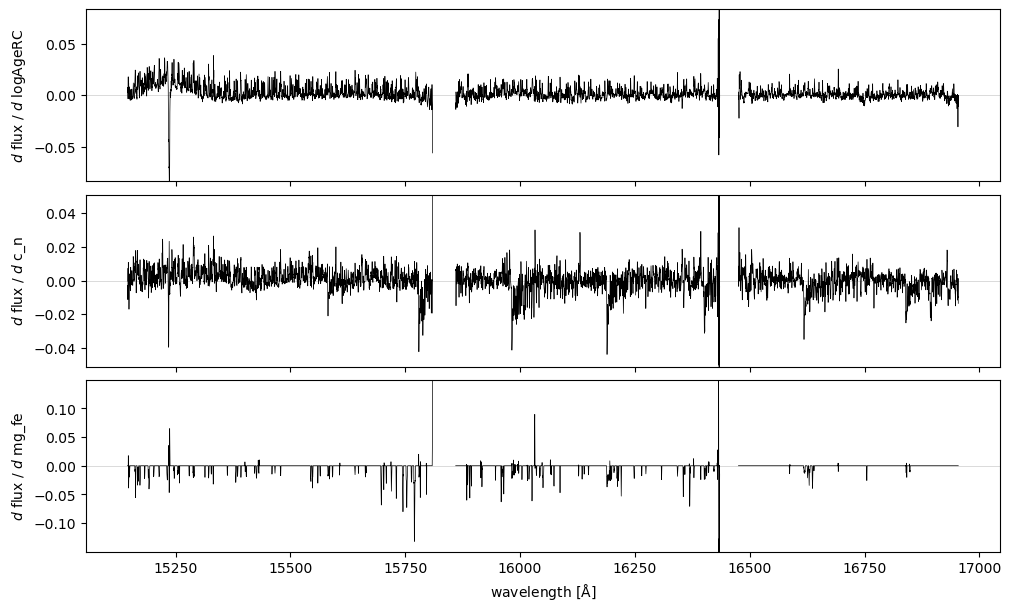

In [19]:
# Diagnostic: where does each label actually get its spectral signal?
# First-order theta coefficients of the final model vs wavelength. Theta is
# in scaled-label units -- flux change per ~1-sigma label change -- so real
# coefficients are ~0.01-0.1. Chip-gap / band-edge pixels (no data, so theta
# is unconstrained and huge) are masked via `good_pix` from the censor cell,
# and the y-limits are robust so a few remaining spikes cannot flatten the
# plot. With c_n out of the label vector, logAgeRGB should show dense CN
# structure across the band; a flat coefficient means no spectral leverage
# (and test-step ages that are just the sample mean).
theta_final = np.asarray(model.theta)
disp_A = np.asarray(dispersion)
show = [l for l in ('logAgeRC', 'c_n', 'mg_fe') if l in LABEL_NAMES]
fig, laxes = plt.subplots(len(show), 1, figsize=(10, 2.0 * len(show)),
                          sharex=True, constrained_layout=True)
for ax, l in zip(np.atleast_1d(laxes), show):
    coef = np.where(good_pix, theta_final[:, 1 + LABEL_NAMES.index(l)], np.nan)
    ax.plot(disp_A, coef, lw=0.5, color="k")
    ax.axhline(0, color="0.8", lw=0.5, zorder=-1)
    lim = 1.2 * np.nanpercentile(np.abs(coef), 99.9)
    ax.set_ylim(-lim, lim)
    ax.set_ylabel(f"$d$ flux / $d$ {l}")
ax.set_xlabel(r"wavelength [$\mathrm{\AA}$]")

In [20]:
# Is the age structure above real signal or per-pixel fit noise? Split-half
# test: train two independent linear probes on random halves of the sample
# and correlate their first-order coefficients pixel by pixel (good pixels
# only). Real spectral leverage reproduces in both halves (r well above 0);
# noise does not (r ~ 0). raw_teff is the positive control (expect r close
# to 1); read logAgeRGB's r as the fraction of its coefficient structure
# that is actually age information the test step can use.
half_rng = np.random.RandomState(999)
half = half_rng.permutation(len(finite_idx)) % 2 == 0
coefs = {}
for h, sel in (("A", half), ("B", ~half)):
    p = tc.CannonModel(
        labels_f[sel], flux_f[sel], ivar_f[sel],
        tc.vectorizer.PolynomialVectorizer(label_names=LABEL_NAMES, order=1),
        dispersion=dispersion)
    p.train(progressbar=False)
    coefs[h] = np.asarray(p.theta)
for l in LABEL_NAMES:
    a = coefs["A"][good_pix, 1 + LABEL_NAMES.index(l)]
    b = coefs["B"][good_pix, 1 + LABEL_NAMES.index(l)]
    r = np.corrcoef(a, b)[0, 1]
    print(f"{l:>12}: split-half coefficient correlation r = {r:+.3f}")

2026-07-08 19:34:05,951 [INFO] Training 8-label CannonModel with 2357 stars and 8575 pixels/star
INFO:thecannon.model:Training 8-label CannonModel with 2357 stars and 8575 pixels/star
2026-07-08 19:34:08,585 [INFO] Training 8-label CannonModel with 2357 stars and 8575 pixels/star
INFO:thecannon.model:Training 8-label CannonModel with 2357 stars and 8575 pixels/star


    raw_teff: split-half coefficient correlation r = +0.926
    raw_logg: split-half coefficient correlation r = +0.797
    raw_fe_h: split-half coefficient correlation r = +0.977
       mg_fe: split-half coefficient correlation r = +0.884
         c_n: split-half coefficient correlation r = +0.794
       al_fe: split-half coefficient correlation r = +0.749
       ce_fe: split-half coefficient correlation r = +0.740
    logAgeRC: split-half coefficient correlation r = +0.735


In [21]:
# Flag (but do NOT remove) validation outliers, so the quoted statistics stay
# honest: a star is an outlier if its residual in any label is more than
# 3 robust-sigma (1.48*MAD) from the median residual, or if any prediction is
# non-finite. Outliers are shown in grey in the one-to-one plot below but are
# still included in the bias/scatter statistics.
resids = val_labels - truth
med = np.nanmedian(resids, axis=0)
robust_sigma = 1.4826 * np.nanmedian(np.abs(resids - med), axis=0)
finite_pred = np.all(np.isfinite(val_labels), axis=1)
outlier = ~(np.all(np.abs(resids - med) < 3 * robust_sigma, axis=1) & finite_pred)
print(f"{outlier.sum()} of {len(outlier)} validation stars flagged as outliers "
      "(plotted in grey; still counted in the statistics)")

555 of 4714 validation stars flagged as outliers (plotted in grey; still counted in the statistics)


In [22]:
# Flag (but do not remove) physically unreasonable age predictions: older
# than 20 Gyr. (logAgeRGB is log10 of the age in Gyr, so 10**pred > 0 by
# construction -- only the upper bound can fail; NaN predictions are
# already flagged above.)
if 'logAgeRC' in LABEL_NAMES:
    age_idx = LABEL_NAMES.index('logAgeRC')
    age_gyr = 10**val_labels[:, age_idx]
    unphysical = np.isfinite(age_gyr) & (age_gyr >= 20)
    print(f"{unphysical.sum()} predicted ages fall outside 0-20 Gyr")
    outlier |= unphysical

8 predicted ages fall outside 0-20 Gyr


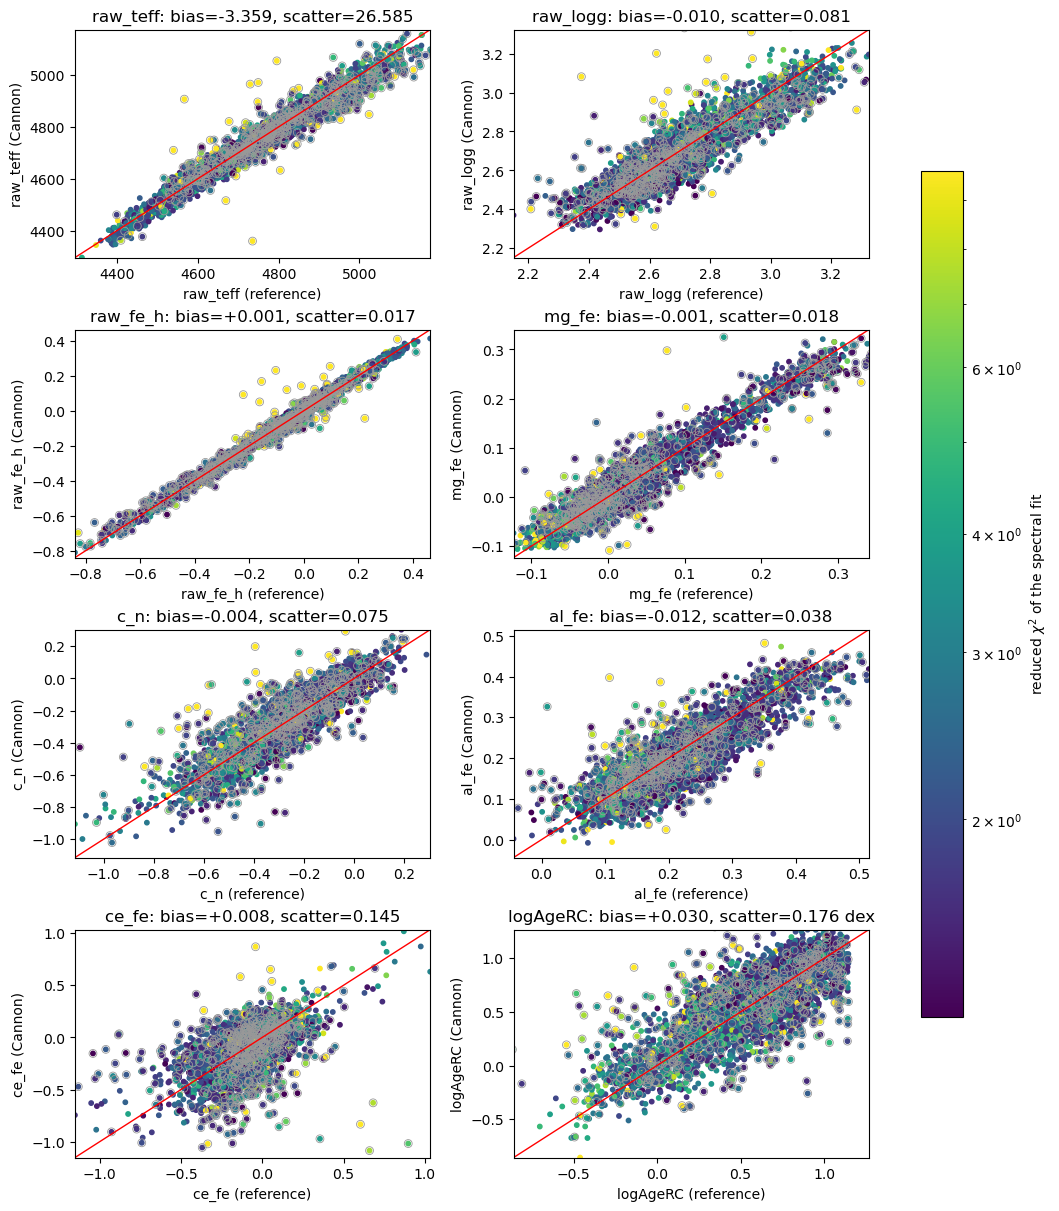

In [23]:
# One-to-one comparison of Cannon-predicted vs ASPCAP/seismic labels on ALL
# out-of-fold predictions. No sigma clipping: the quoted bias/scatter are
# robust statistics (median and 1.48*MAD) over all finite points. Points are
# colored by the test-step reduced chi^2 -- how well the model reconstructs
# each SPECTRUM -- so poorly-fit spectra can be spotted directly; label
# outliers (from the cells above) keep a grey ring. Age is compared in log
# space (dex), where the scatter is not dominated by the oldest stars.
from matplotlib.colors import LogNorm

chi_ok = np.isfinite(val_chi2) & (val_chi2 > 0)
chi_lo, chi_hi = np.percentile(val_chi2[chi_ok], [2, 98])
chi_norm = LogNorm(vmin=chi_lo, vmax=chi_hi)     # robust limits; chi^2 is heavy-tailed

nrows = (len(LABEL_NAMES) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(10.5, 2.5 * nrows + 2),
                         constrained_layout=True)
axes = axes.ravel()
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    x, y = truth[:, i], val_labels[:, i]
    ok = np.isfinite(x) & np.isfinite(y)
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    sc = ax.scatter(x[ok], y[ok], c=val_chi2[ok], s=10,
                    cmap="viridis", norm=chi_norm)
    ax.scatter(x[ok & outlier], y[ok & outlier], facecolor="none",
               edgecolor="0.6", linewidth=0.6, s=32)
    # Axis limits from the non-outlier points; ringed outliers may fall outside.
    xg, yg = x[ok & ~outlier], y[ok & ~outlier]
    lims = [min(xg.min(), yg.min()), max(xg.max(), yg.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims); ax.set_ylim(lims)
    unit = " dex" if name == "logAgeRC" else ""
    ax.set_xlabel(f"{name} (reference)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={bias:+.3f}, scatter={scatter:.3f}{unit}")
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
fig.colorbar(sc, ax=list(axes[:len(LABEL_NAMES)]), shrink=0.75,
             label=r"reduced $\chi^2$ of the spectral fit")

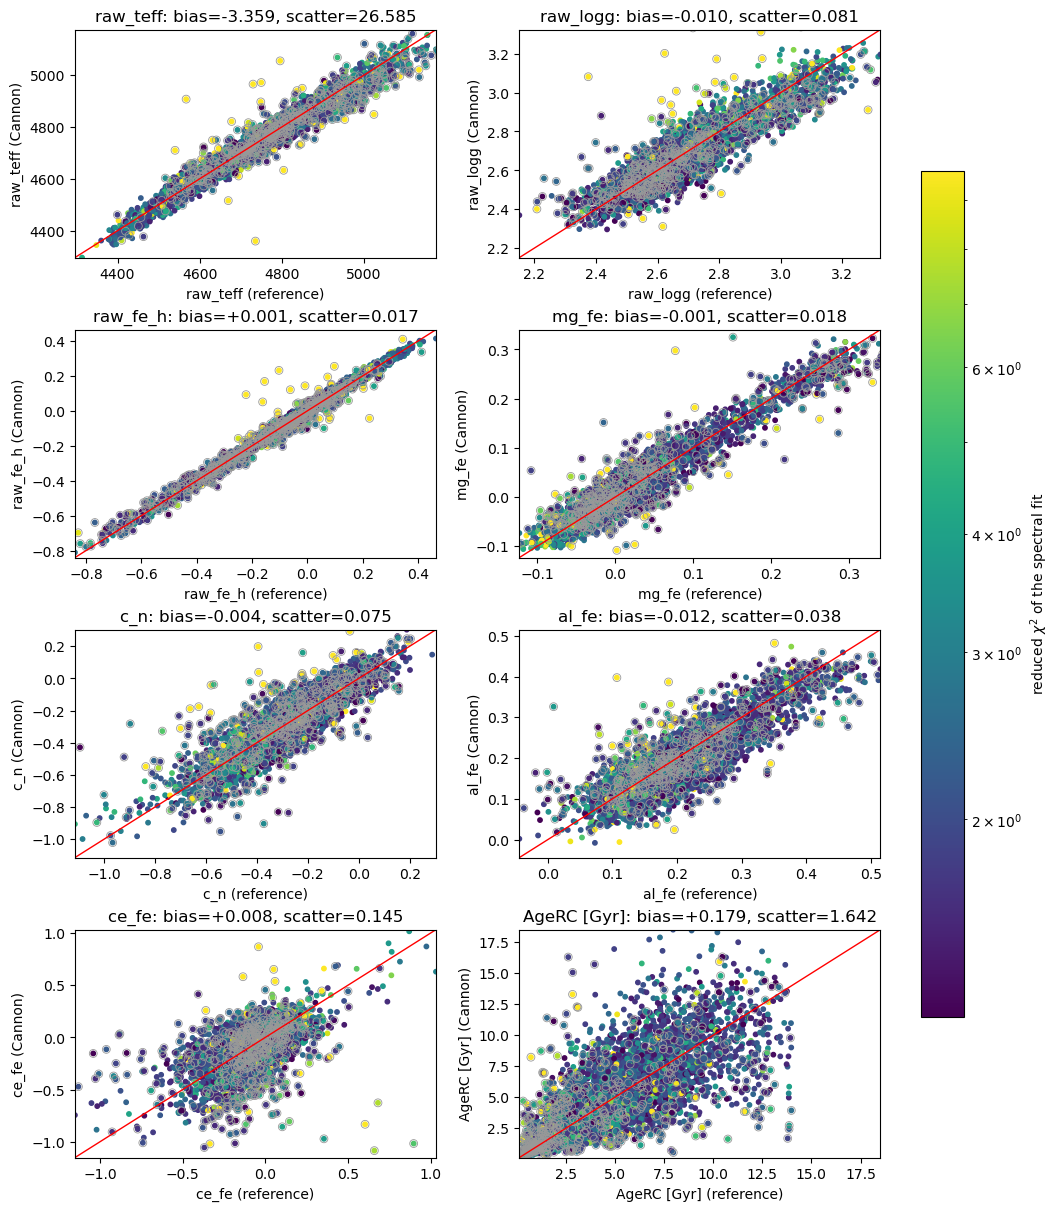

In [24]:
# Same one-to-one comparison, but with age in LINEAR Gyr. Points are colored
# by the test-step reduced chi^2 of the spectral fit (shared color scale with
# the log-space figure above); label outliers keep a grey ring.
nrows = (len(LABEL_NAMES) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(10.5, 2.5 * nrows + 2),
                         constrained_layout=True)
axes = axes.ravel()
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    x, y = truth[:, i], val_labels[:, i]
    ok = np.isfinite(x) & np.isfinite(y)
    if name == 'logAgeRC':
        name = 'AgeRC [Gyr]'
        x = 10**x
        y = 10**y
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    sc = ax.scatter(x[ok], y[ok], c=val_chi2[ok], s=10,
                    cmap="viridis", norm=chi_norm)
    ax.scatter(x[ok & outlier], y[ok & outlier], facecolor="none",
               edgecolor="0.6", linewidth=0.6, s=32)
    # Axis limits from the non-outlier points; ringed outliers may fall outside.
    xg, yg = x[ok & ~outlier], y[ok & ~outlier]
    lims = [min(xg.min(), yg.min()), max(xg.max(), yg.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{name} (reference)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={bias:+.3f}, scatter={scatter:.3f}")
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
fig.colorbar(sc, ax=list(axes[:len(LABEL_NAMES)]), shrink=0.75,
             label=r"reduced $\chi^2$ of the spectral fit")

In [25]:
np.percentile(val_chi2, 86)

np.float64(4.09049640461151)

(array([ 664., 2157.,  943.,  389.,  212.,   93.,   63.,   54.,   29.,
          23.]),
 array([0.66860701, 1.59996309, 2.53131918, 3.46267526, 4.39403135,
        5.32538743, 6.25674352, 7.18809961, 8.11945569, 9.05081178,
        9.98216786]),
 <BarContainer object of 10 artists>)

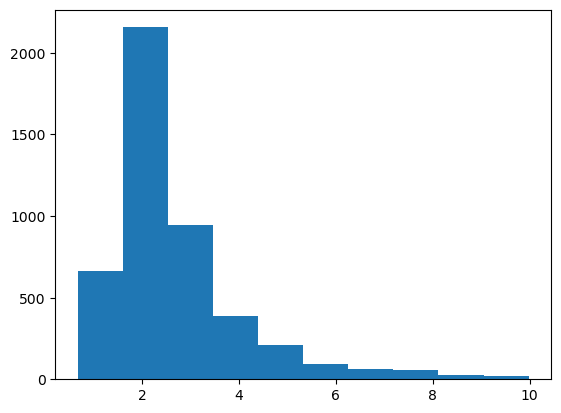

In [26]:
normal_val_chi2 = val_chi2[val_chi2<10]
plt.hist(normal_val_chi2)

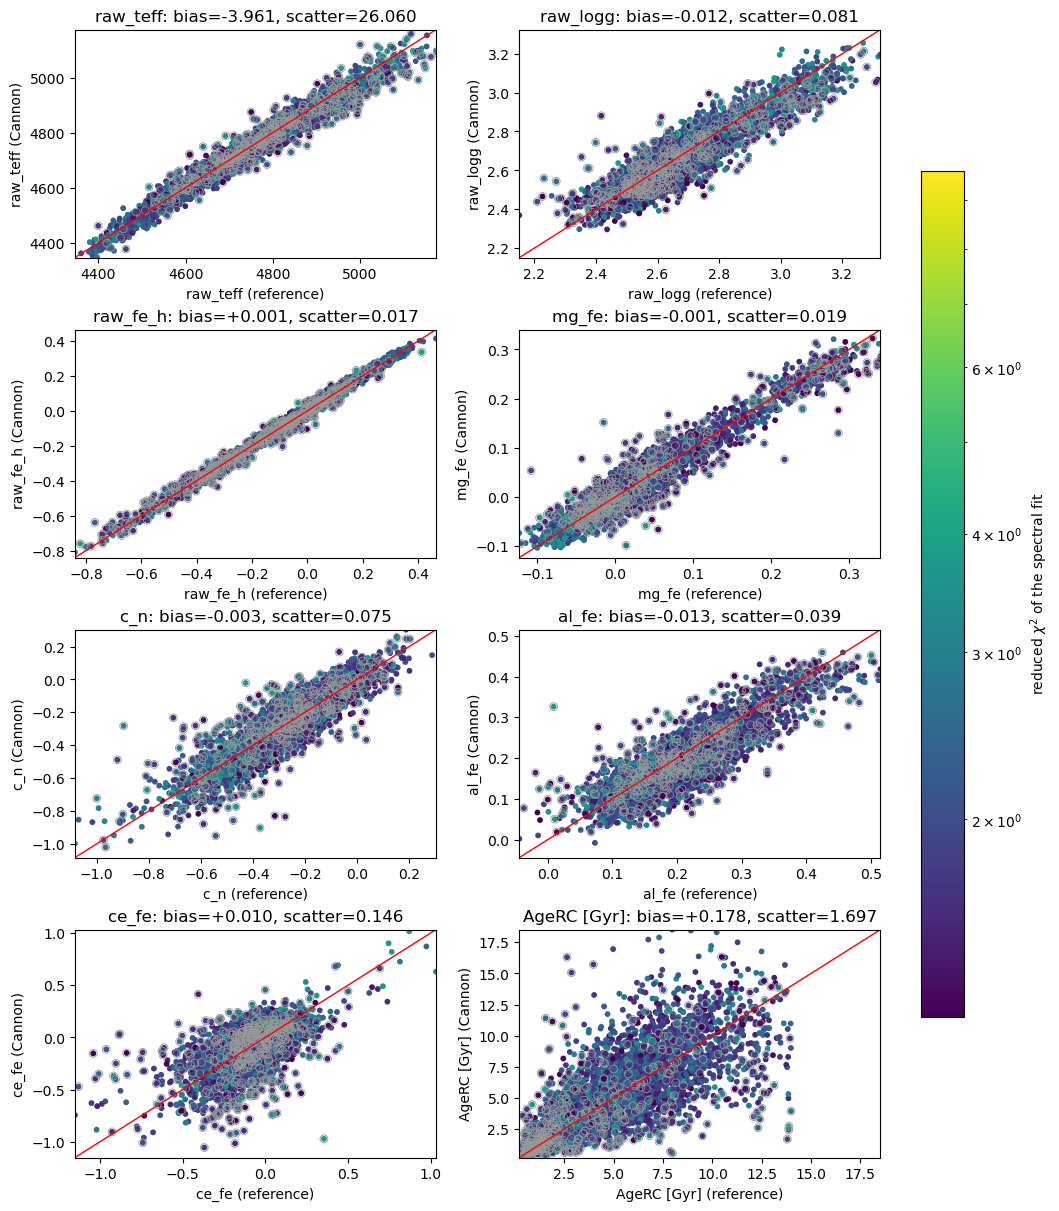

In [27]:
# Same one-to-one comparison (age in LINEAR Gyr), but restricted to well-fit
# spectra: only stars whose test-step reduced chi^2 is below the 86th
# percentile (~2.1, see the cells above) enter the plots and the quoted
# statistics. Points are colored by chi^2 on the shared color scale; label
# outliers keep a grey ring.
chisq_mask = val_chi2 <= np.percentile(val_chi2, 84)

nrows = (len(LABEL_NAMES) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(10.5, 2.5 * nrows + 2),
                         constrained_layout=True)
axes = axes.ravel()
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    x, y = truth[:, i], val_labels[:, i]
    ok = np.isfinite(x) & np.isfinite(y) & chisq_mask
    if name == 'logAgeRC':
        name = 'AgeRC [Gyr]'
        x = 10**x
        y = 10**y
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    sc = ax.scatter(x[ok], y[ok], c=val_chi2[ok], s=10,
                    cmap="viridis", norm=chi_norm)
    ax.scatter(x[ok & outlier], y[ok & outlier], facecolor="none",
               edgecolor="0.6", linewidth=0.6, s=32)
    # Axis limits from the non-outlier points (with the chi^2 cut applied)
    xg, yg = x[ok & ~outlier], y[ok & ~outlier]
    lims = [min(xg.min(), yg.min()), max(xg.max(), yg.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(f"{name} (reference)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={bias:+.3f}, scatter={scatter:.3f}")
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
fig.colorbar(sc, ax=list(axes[:len(LABEL_NAMES)]), shrink=0.75,
             label=r"reduced $\chi^2$ of the spectral fit")

In [28]:
# Save the trained model to disk (absolute path via SRC -- a bare relative
# path would land wherever the notebook server was started).
model.write(str(SRC / "trained_cannon_model_rc.pkl"), overwrite=True)